<a href="https://colab.research.google.com/github/Mundiamercy/BCS-03-0037-2026/blob/main/Dropped_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded= files.upload()

Saving students_dataset (1).xlsx to students_dataset (1).xlsx


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel("students_dataset (1).xlsx")
df.head()

,stud_id,age_yrs,sex,course_taken,yr_of_study,att_perc,study_hrs_week,assgn_score,final_exam,fam_income_kes,transport_mode,phone_no,lecturer_notes,temp_var_delete
0,STU1000,23.0,Male,Statistics,1,79.5,21.6,50.4,75.7,38134.0,Boda,732008519,Good,36
1,STU1001,31.0,F,Statistics,3,94.8,22.2,46.3,64.4,47400.0,Bus,762821494,Late,97
2,STU1002,27.0,female,Computer Science,2,67.9,18.0,63.3,91.5,57427.0,bus,797929059,-,15
3,STU1003,24.0,male,Applied Maths,4,92.4,20.0,51.7,64.8,34452.0,Boda,795081844,Needs follow-up,62
4,STU1004,23.0,Male,Computer Science,4,47.1,21.1,66.7,70.7,32719.0,MATATU,768986770,Excellent,3


#look at column names

In [ ]:
print(df.columns)

Index(['stud_id', 'age_yrs', 'sex', 'course_taken', 'yr_of_study', 'att_perc',
       'study_hrs_week', 'assgn_score', 'final_exam', 'fam_income_kes',
       'transport_mode', 'phone_no', 'lecturer_notes', 'temp_var_delete'],
      dtype='object')


# NUMBER OF the last ROWS(OBSERVATIONS)



In [ ]:
df.tail()

,stud_id,age_yrs,sex,course_taken,yr_of_study,att_perc,study_hrs_week,assgn_score,final_exam,fam_income_kes,transport_mode,phone_no,lecturer_notes,temp_var_delete
1220,STU2006,23.0,Male,Statistics,3,69.1,12.1,82.4,81.6,19552.0,bus,746695628,Late,45
1221,STU1306,24.0,F,Computer Science,2,94.5,11.7,61.4,97.7,29419.0,Private,715939738,Late,32
1222,STU2092,29.0,female,Data Science,3,75.4,18.7,50.0,100.0,28000.0,bus,713795390,Needs follow-up,92
1223,STU1568,26.0,male,Applied Maths,1,80.3,16.0,64.5,84.7,38402.0,Walk,714224735,Late,44
1224,STU1220,19.0,F,IT,1,80.6,18.2,NaN,60.7,35652.0,Bus,742744027,NaN,31


#check unique values in categorical fields

In [ ]:
print(df['sex'].unique())

['Male' 'F' 'female' 'male' 'Female' 'M']


In [ ]:
print(df['transport_mode'].unique())
print(df['lecturer_notes'].unique())


['Boda' 'Bus' 'bus' 'MATATU' 'Matatu' 'Walk' 'Private']
['Good' 'Late' '-' 'Needs follow-up' 'Excellent' nan]


#Dropping unnecessary columns

In [ ]:
df.drop('stud_id',axis=1,inplace=True)

#check for missing values

In [ ]:
df.isnull().sum()

,0
age_yrs,25
sex,0
course_taken,0
yr_of_study,0
att_perc,0
study_hrs_week,0
assgn_score,27
final_exam,25
fam_income_kes,25
transport_mode,0


#filling age in years"temporary"

In [ ]:
df.age_yrs.mean()

np.float64(25.9675)

Replace all missing values with (25.9)

In [ ]:
df.age_yrs.fillna(25.9)

,age_yrs
0,23.0
1,31.0
2,27.0
3,24.0
4,23.0
...,...
1220,23.0
1221,24.0
1222,29.0
1223,26.0


#Using mode in assignment score

In [ ]:
df.assgn_score.mode()

,assgn_score
0,100.0


#Replacing all the missing values in assign-score with (100)

In [ ]:
df.assgn_score.fillna(100)

,assgn_score
0,50.4
1,46.3
2,63.3
3,51.7
4,66.7
...,...
1220,82.4
1221,61.4
1222,50.0
1223,64.5


#Using the median to fill in the final exam score

In [ ]:
df.final_exam.median()

62.05

In [ ]:
df.final_exam.fillna(62.05)

,final_exam
0,75.7
1,64.4
2,91.5
3,64.8
4,70.7
...,...
1220,81.6
1221,97.7
1222,100.0
1223,84.7


#Using the forward fill method to fill fam_income_kes

In [ ]:
df.fam_income_kes.fillna(1225)

,fam_income_kes
0,38134.0
1,47400.0
2,57427.0
3,34452.0
4,32719.0
...,...
1220,19552.0
1221,29419.0
1222,28000.0
1223,38402.0


In [ ]:
df.lecturer_notes.unique()

array(['Good', 'Late', '-', 'Needs follow-up', 'Excellent', nan],
      dtype=object)

#check nulls in the missing values of the lecture_notes

In [ ]:
df.lecturer_notes.isnull().sum()

np.int64(206)

Checking duplicates

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1220,True
1221,True
1222,True
1223,True


,0
0,False
1,False
2,False
3,False
4,False
...,...
1220,True
1221,True
1222,True
1223,True


In [ ]:
df.duplicated().sum()

np.int64(23)

deleting the duplicates permanantly

In [ ]:
df.drop_duplicates()

,age_yrs,sex,course_taken,yr_of_study,att_perc,study_hrs_week,assgn_score,final_exam,fam_income_kes,transport_mode,phone_no,lecturer_notes,temp_var_delete
0,23.0,Male,Statistics,1,79.5,21.6,50.4,75.7,38134.0,Boda,732008519,Good,36
1,31.0,F,Statistics,3,94.8,22.2,46.3,64.4,47400.0,Bus,762821494,Late,97
2,27.0,female,Computer Science,2,67.9,18.0,63.3,91.5,57427.0,bus,797929059,-,15
3,24.0,male,Applied Maths,4,92.4,20.0,51.7,64.8,34452.0,Boda,795081844,Needs follow-up,62
4,23.0,Male,Computer Science,4,47.1,21.1,66.7,70.7,32719.0,MATATU,768986770,Excellent,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197,24.0,F,Statistics,1,100.0,11.4,69.6,36.3,50921.0,Private,797695546,Late,42
1198,28.0,male,Economics,3,90.4,22.6,89.6,71.1,2759.0,Walk,717720837,-,66
1199,23.0,Male,Economics,4,69.6,16.1,100.0,97.1,36480.0,Matatu,786003510,NaN,30
1202,35.0,M,Applied Maths,2,69.7,-4.0,51.4,41.2,20074.0,bus,730239566,Good,52


#Query the unique value in lecturere_notes

In [ ]:
df.lecturer_notes.unique()

array(['Good', 'Late', '-', 'Needs follow-up', 'Excellent', nan],
      dtype=object)

In [ ]:
import numpy as np


#Dealing with the hypen in lecturer_notes

In [ ]:
df.lecturer_notes.replace('-',np.nan)

,lecturer_notes
0,Good
1,Late
2,NaN
3,Needs follow-up
4,Excellent
...,...
1220,Late
1221,Late
1222,Needs follow-up
1223,Late


,lecturer_notes
0,Good
1,Late
2,NaN
3,Needs follow-up
4,Excellent
...,...
1220,Late
1221,Late
1222,Needs follow-up
1223,Late


In [ ]:
df.lecturer_notes=df.lecturer_notes.replace('-',np.nan)

#Filling the missing values in lecturer_notes variables using the forward fill

In [ ]:
df.lecturer_notes.value_counts()

,count
lecturer_notes,
Good,225
Late,214
Excellent,203
Needs follow-up,190


3Query unique values in sex

In [ ]:
df.sex.unique()

array(['Male', 'F', 'female', 'male', 'Female', 'M'], dtype=object)

In [ ]:
df.sex.value_counts()

,count
sex,
female,218
F,216
Female,212
Male,202
male,197
M,180


,count
sex,
female,218
F,216
Female,212
Male,202
male,197
M,180


Standardizing

In [ ]:
df.sex.replace({'female':'Female','F':'Female','male':'Male','M':'Male'})

,sex
0,Male
1,Female
2,Female
3,Male
4,Male
...,...
1220,Male
1221,Female
1222,Female
1223,Male


#Query the unique value in transport mode used

In [ ]:
df.transport_mode.value_counts()

,count
transport_mode,
Walk,218
Private,211
bus,207
Boda,201
Matatu,188
Bus,180
MATATU,20


#Outliers- Refer to values in a dataset that deviate beyond the maximum or minimum values
#I.Q.R-> Interquartile range
#Z-Score method-.Normal distribution

In [ ]:
import seaborn as sns

<Axes: ylabel='age_yrs'>

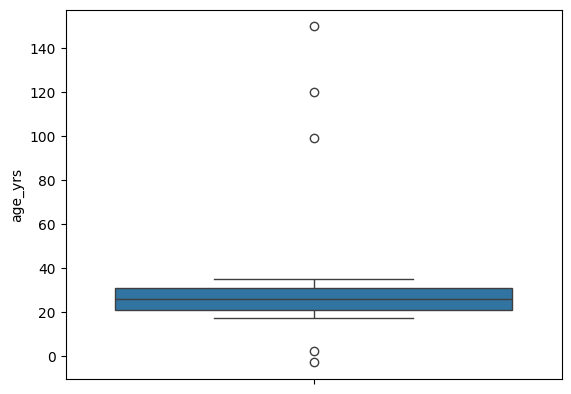

In [ ]:
sns.boxplot(y='age_yrs',data=df)

#Displaying the outliers

#1st outlier

In [ ]:
Q1=df.age_yrs.quantile(0.25)
Q1

np.float64(21.0)

3rd Outlier

In [ ]:
Q3=df.age_yrs.quantile(0.75)
Q3

np.float64(31.0)

# IQR

In [ ]:
IQR=Q3-Q1
Q1

np.float64(21.0)

In [ ]:
lower_limit=Q1-1.5*IQR
lower_limit

np.float64(6.0)

In [ ]:
upper_limit=Q3+1.5*IQR
upper_limit

np.float64(46.0)

In [ ]:
df[(df.age_yrs<lower_limit)|(df.age_yrs>upper_limit)]

,age_yrs,sex,course_taken,yr_of_study,att_perc,study_hrs_week,assgn_score,final_exam,fam_income_kes,transport_mode,phone_no,lecturer_notes,temp_var_delete
171,120.0,M,IT,1,55.1,21.6,63.5,93.7,49955.0,Bus,753070452,Good,3
288,2.0,F,IT,4,80.6,11.7,21.4,61.2,26642.0,Boda,772683466,Good,73
640,99.0,Male,Economics,1,68.2,7.3,60.9,37.7,28106.0,Bus,750993362,Late,73
690,150.0,Male,Computer Science,4,87.9,4.1,73.7,100.0,17361.0,MATATU,738399026,Good,74
867,-3.0,Male,Statistics,1,100.0,17.2,80.5,29.8,32931.0,Matatu,798214063,NaN,20


#Deleting the ouliers

In [ ]:
df[(df.age_yrs>lower_limit)&(df.age_yrs<upper_limit)]

,age_yrs,sex,course_taken,yr_of_study,att_perc,study_hrs_week,assgn_score,final_exam,fam_income_kes,transport_mode,phone_no,lecturer_notes,temp_var_delete
0,23.0,Male,Statistics,1,79.5,21.6,50.4,75.7,38134.0,Boda,732008519,Good,36
1,31.0,F,Statistics,3,94.8,22.2,46.3,64.4,47400.0,Bus,762821494,Late,97
2,27.0,female,Computer Science,2,67.9,18.0,63.3,91.5,57427.0,bus,797929059,NaN,15
3,24.0,male,Applied Maths,4,92.4,20.0,51.7,64.8,34452.0,Boda,795081844,Needs follow-up,62
4,23.0,Male,Computer Science,4,47.1,21.1,66.7,70.7,32719.0,MATATU,768986770,Excellent,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,23.0,Male,Statistics,3,69.1,12.1,82.4,81.6,19552.0,bus,746695628,Late,45
1221,24.0,F,Computer Science,2,94.5,11.7,61.4,97.7,29419.0,Private,715939738,Late,32
1222,29.0,female,Data Science,3,75.4,18.7,50.0,100.0,28000.0,bus,713795390,Needs follow-up,92
1223,26.0,male,Applied Maths,1,80.3,16.0,64.5,84.7,38402.0,Walk,714224735,Late,44
